In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

base_dir = os.path.dirname(os.path.dirname(os.getcwd()))
data_dir = os.path.join(base_dir, 'data', 'processed_data', 'House2_full.csv')
train_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.csv')
test_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.csv')
train_h5_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.h5')
test_h5_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.h5')
sys.path.append(base_dir)
train_npy_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.npy')
test_npy_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.npy')
test_visualize_dir = os.path.join(base_dir, 'data', 'test', 'test_house2_for_visualize.npy')

from src.tools.window_shifter import WindowShifter
from src.metrics.energy_base_metrics import MAE, NEP, Precision_energy_based, Recall_energy_based, F1_energy_based

In [41]:
train_npy = np.load(train_npy_dir)
test_npy = np.load(test_npy_dir)

In [42]:
train_target = train_npy[:,-9:]
test_target = test_npy[:,-9:]

# Tìm threshold bật tắt

In [2]:
on_threshold = {
    'Appliance1': 15,    # Fridge-Freezer: may nen chay ~50-150W
    'Appliance2': 20,    # Washing Machine: nhieu che do tu 20W
    'Appliance3': 10,    # Dishwasher: che do nhe tu 10W
    'Appliance4': 10,    # Television: xem TV 50-200W
    'Appliance5': 20,   # Microwave: cong suat cao, standby rat thap
    'Appliance6': 20,   # Toaster: cong suat cao, bat cuc ngan
    'Appliance7': 5,    # Hi-Fi: cong suat thap
    'Appliance8': 2000,   # Kettle: cong suat rat cao 2000-3000W
    'Appliance9': 15,    # Oven Extractor Fan: quat hut
}

In [3]:
threshold = list(on_threshold.values())

In [45]:
train_target.shape

(4586581, 9)

In [46]:
test_target.shape

(573322, 9)

In [47]:
sum(train_target[:,0]>=threshold[0])  # app1 train

np.int64(1845106)

In [48]:
sum(test_target[:,0]>=threshold[0])  # app1 test

np.int64(206633)

In [49]:
sum(train_target[:,1]>=threshold[1])  # app2 train

np.int64(170141)

In [50]:
pos_weight_2 = (4586581 - 170141)/170141
pos_weight_2

25.95752934330937

In [51]:
sum(train_target[:,2]>=threshold[2])

np.int64(362023)

In [52]:
pos_weight_3 = (4586581 - 362023)/362023
pos_weight_3

11.669308303616068

In [53]:
sum(train_target[:,3]>=threshold[3])

np.int64(421622)

In [54]:
pos_weight_4 = (4586581 - 421622)/421622
pos_weight_4

9.8784195321876

In [55]:
sum(train_target[:,4]>=threshold[4])

np.int64(33166)

In [56]:
pos_weight_5 = (4586581 - 33166)/33166
pos_weight_5

137.29165410360008

In [57]:
sum(train_target[:,5]>=threshold[5])

np.int64(10737)

In [58]:
pos_weight_6 = (4586581 - 10737)/10737
pos_weight_6

426.1752817360529

In [59]:
sum(train_target[:,6]>=threshold[6])

np.int64(576452)

In [60]:
pos_weight_7 = (4586581 - 576452)/576452
pos_weight_7

6.956570538396952

In [61]:
sum(train_target[:,7]>=threshold[7])

np.int64(36889)

In [62]:
pos_weight_8 = (4586581 - 36889)/36889
pos_weight_8

123.33465260646805

In [63]:
sum(train_target[:,8]>=threshold[8])

np.int64(29697)

In [64]:
pos_weight_8 = (4586581 - 29697)/29697
pos_weight_8

153.44593730006397

In [4]:
import numpy as np
import torch
from torch.utils.data import Dataset

class NILMDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.transform = transform
        npy_dir = data_dir.replace('.h5', '.npy')
        self.data_matrix = np.load(data_dir, mmap_mode='r')
        self.total_lines = self.data_matrix.shape[0]

    def __len__(self):
        return self.total_lines

    def __getitem__(self, idx):
        row = self.data_matrix[idx] 
        data = torch.tensor(row[:-9], dtype=torch.float32)
        label = torch.tensor(row[-9:], dtype=torch.float32)
        if self.transform:
            data = self.transform(data)
        data = data.unsqueeze(dim = 0)
        return data, label


In [5]:
train_dataset = NILMDataset(train_npy_dir)
test_dataset = NILMDataset(test_npy_dir)
visualize_dataset = NILMDataset(test_visualize_dir)

In [6]:
batch_size = 1024
train_loader = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True, num_workers = 0)
test_loader = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = True, num_workers = 0)
visualize_loader = DataLoader(dataset = visualize_dataset, batch_size = batch_size, shuffle = False, num_workers = 0)

In [7]:
class S2PwaRegressor(nn.Module):
    def __init__(self, window_length = 300, in_channels = 1, filter_nums = 32, kernel_size = 3, hidden_dim = 64):
        super().__init__()
        self.window_length = window_length

        # Encoder
        self.conv1 = nn.Conv1d(in_channels, out_channels = filter_nums, kernel_size = kernel_size, padding = kernel_size//2)
        self.conv2 = nn.Conv1d(in_channels = 32, out_channels  = filter_nums, kernel_size = kernel_size, padding = kernel_size//2)
        self.bilstm = nn.LSTM(input_size = 32, hidden_size = hidden_dim, batch_first = True, bidirectional = True)
        bilstm_out_dim = hidden_dim * 2 # concat 2 vector của hidden state theo 2 chiều

        # Attention
        self.v_a = nn.Linear(hidden_dim, 1, bias = False)
        self.att_dense = nn.Linear(bilstm_out_dim, hidden_dim)
        self.att_softmax = nn.Softmax(dim = 1)
        
        # thay đổi kiến trúc cũ
        # đầu ra của attention là batch, bilstm_out_dim
        self.fc1 = nn.Linear(bilstm_out_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64,1)
    
    def forward(self, x):
        # x sau khi lấy ra từ dataloader đang có dạng batch, channels, length
        x = self.conv1(x)
        x = self.conv2(x)
        # lstm mong đợi đầu vào dạng batch, length, channels
        x = x.permute(0,2,1) 
        h_t, _ = self.bilstm(x) 
        # h_t có dạng batch, length, hidden_dim*2
        energy = nn.Tanh()(self.att_dense(h_t)) # batch, length, hidden_dim
        score = self.v_a(energy) # batch, length, 1 (có thể hiểu là có l hidden state mối hidden state có 1 trọng số riêng để thể hiện sự đóng góp)
        alpha_t = self.att_softmax(score) # batch, length, 1
        c = (h_t * alpha_t).sum(dim = 1) # batch, hidden_dim * 2
        x = self.fc1(c) # batch, 64
        x = self.relu(x) 
        x = self.fc2(x) # batch, 1
        return x

In [35]:
sum([p.numel() for p in S2PwaRegressor().parameters() if p.requires_grad])

70049

In [8]:
import torch
import torch.nn as nn

class S2qwaClassifier(nn.Module):
    def __init__(self, window_length=300):
        super().__init__()
        self.activation = nn.ReLU()     
        
        self.cv1 = nn.Conv1d(in_channels=1, out_channels=30, kernel_size=10)
        self.bn1 = nn.BatchNorm1d(30)
        
        self.cv2 = nn.Conv1d(in_channels=30, out_channels=30, kernel_size=8)
        self.bn2 = nn.BatchNorm1d(30)
        
        self.cv3 = nn.Conv1d(in_channels=30, out_channels=40, kernel_size=6)
        self.bn3 = nn.BatchNorm1d(40)
        
        self.cv4 = nn.Conv1d(in_channels=40, out_channels=50, kernel_size=5)
        self.bn4 = nn.BatchNorm1d(50)
        
        self.cv5 = nn.Conv1d(in_channels=50, out_channels=50, kernel_size=5)
        self.bn5 = nn.BatchNorm1d(50)
        
        self.cv6 = nn.Conv1d(in_channels=50, out_channels=50, kernel_size=5)
        self.bn6 = nn.BatchNorm1d(50)
        
        # tổng lượng hao hụt: 9 + 7 + 5 + 4 + 4 + 4 = 33
        l_out = window_length - 33 
        self.flatten_size = 50 * l_out   
        
        self.dense1 = nn.Linear(in_features=self.flatten_size, out_features=128)
        self.dropout1 = nn.Dropout(0.5)
        
        self.dense2 = nn.Linear(in_features=128, out_features=32)
        self.dropout2 = nn.Dropout(0.3)
        
        self.dense3 = nn.Linear(in_features=32, out_features=1)

    def forward(self, x):
        x = self.activation(self.bn1(self.cv1(x)))
        x = self.activation(self.bn2(self.cv2(x)))
        x = self.activation(self.bn3(self.cv3(x)))
        x = self.activation(self.bn4(self.cv4(x)))
        x = self.activation(self.bn5(self.cv5(x)))
        x = self.activation(self.bn6(self.cv6(x))) 
        x = x.view(x.size(0), -1)         
        x = self.activation(self.dropout1(self.dense1(x)))
        x = self.activation(self.dropout2(self.dense2(x)))
        x = self.dense3(x) 
        return x


# Chú ý

Đầu ra của classifier là logit thô sau đó mới áp dụng bceloss, nếu logit bé hơn 0 thì sigmoid của logit<0.5 pred là 0 ngược lại là 1

In [37]:
sum([p.numel() for p in S2qwaClassifier().parameters() if p.requires_grad])

1763539

# Chú ý

Dưới đây là các thông số cơ bản cho việc chuẩn hóa trong code của protocol s2p fast đẫ tính rồi giờ tính lại chỉ tổ mất thêm ram nên lấy luôn vì chúng là hằng số

Đối với input thì chuẩn hóa theo kiểu z score còn đối với target thì chuẩn hóa theo kiểu minimax

In [9]:
app_min = np.array([0., 0., 0., 0., 0., 0., 0., 0., 0.])
app_max = np.array([1639., 2555., 2480.,  512., 1242., 1024., 1536., 2939.,  384.])
train_mean, train_std = (np.float64(494.62987145211497), np.float64(1088.939294395772))

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Chiến thuật

Sử dụng 1 model classifier và 1 mô hình regressor đầu ra sẽ là tích element wise của đầu ra của classifier và regressor

Ở regressor sử dụng chiến thuật masked loss 

# Train classifier

In [11]:
from sklearn.metrics import f1_score
import os

def train_classifier(epochs, save_dir, app_num, device = device, lr = 5e-4, pos_weight = torch.tensor(1.0)):
    ignore_threshold = threshold[app_num - 1]
    classifier = S2qwaClassifier().to(device)
    if os.path.exists(save_dir):
        classifier.load_state_dict(torch.load(save_dir, map_location=device))
    optimizer = torch.optim.Adam(classifier.parameters(), lr = lr, weight_decay = 1e-4) # L2 penalty
    criterion = nn.BCEWithLogitsLoss(pos_weight = pos_weight)
    
    max_f1 = 0.0 
    
    for epoch in range(epochs):
        train_loss = 0.0
        classifier.train()
        for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
            data = (data - train_mean)/train_std
            target = target[:,[app_num - 1]]
            target = torch.where(target >= ignore_threshold, 1.0, 0.0)
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = classifier(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        avg_train_loss = train_loss/(batch_idx + 1)
        print(f'EPOCH: {epoch+1}, average train loss of classifier: {avg_train_loss:.4f}')

        classifier.eval()
        eval_loss = 0.0
        all_preds = []
        all_targets = []
        with torch.no_grad():
            for batch_idx, (data_eval, target_eval) in enumerate(tqdm(test_loader)):
                data_eval = (data_eval - train_mean)/train_std
                target_eval = target_eval[:,[app_num - 1]]
                target_eval = torch.where(target_eval >= ignore_threshold, 1.0, 0.0)
                data_eval, target_eval = data_eval.to(device), target_eval.to(device)
                output = classifier(data_eval)
                loss = criterion(output, target_eval)
                eval_loss += loss.item()               
                preds = (output > 0).int().cpu().numpy()
                all_preds.extend(preds.flatten())
                all_targets.extend(target_eval.int().cpu().numpy().flatten())
                
            avg_eval_loss = eval_loss/(batch_idx + 1)
            current_f1 = f1_score(all_targets, all_preds)
            
            if current_f1 > max_f1:
                max_f1 = current_f1
                torch.save(classifier.state_dict(), save_dir)
                print(f'>>> new best model at {epoch+1} with F1: {current_f1:.4f} <<<')
                
            print(f'EPOCH: {epoch+1}, average eval loss: {avg_eval_loss:.4f}, eval F1-score: {current_f1:.4f}')
            
    print(f'Done training model for appliance {app_num}')


In [12]:
class MaskedL1Loss(nn.Module):
    def __init__(self, ignore_threshold, appliance_min, appliance_max):
        super(MaskedL1Loss, self).__init__()
        self.ignore_threshold = ignore_threshold
        self.appliance_min = appliance_min
        self.appliance_max = appliance_max
    
    def forward(self, pred, target_scaled):
        loss = torch.abs(pred - target_scaled)
        target_watt = target_scaled * (self.appliance_max - self.appliance_min) + self.appliance_min   # chuẩn hóa ngược để xem giá trị nguyên bản có >= ignore_threshold ko
        mask = (target_watt >= self.ignore_threshold).float()
        total_non_masked = mask.sum()
        masked_loss = ((loss * mask).sum())/(total_non_masked + 1e-8)    # tránh mẫu = 0
        return masked_loss

In [13]:
def train_regressor(epochs, save_dir, app_num, device = device, lr = 5e-4):
    ignore_threshold = threshold[app_num - 1]
    regressor = S2PwaRegressor().to(device)
    if os.path.exists(save_dir):
        regressor.load_state_dict(torch.load(save_dir, weights_only=True))
    criterion = MaskedL1Loss(appliance_min = app_min[app_num - 1], appliance_max = app_max[app_num - 1], ignore_threshold = ignore_threshold)                  
    optimizer = torch.optim.Adam(regressor.parameters(), lr = lr)
    min_eval_loss = np.inf
    for epoch in range(epochs):
        regressor.train()
        train_loss = 0.0
        for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
            data = (data - train_mean)/train_std
            target = target[:,[app_num - 1]]
            target = (target - app_min[app_num - 1])/(app_max[app_num - 1] - app_min[app_num - 1])
            data, target = data.to(device).to(torch.float), target.to(device).to(torch.float)
            optimizer.zero_grad()
            output = regressor(data)
            loss = criterion(output, target) 
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        avg_train_loss = train_loss/(batch_idx + 1)
        print(f'EPOCH: {epoch+1}, average train loss: {avg_train_loss}')

        regressor.eval()
        eval_loss = 0.0
        with torch.no_grad():
            for batch_idx, (data_eval, target_eval) in enumerate(tqdm(test_loader)):
                data_eval = (data_eval - train_mean)/train_std
                data_eval = data_eval.to(device)
                target_eval = target_eval[:,[app_num - 1]].to(device)
                target_eval = (target_eval - app_min[app_num - 1])/(app_max[app_num - 1] - app_min[app_num - 1])
                pred = regressor(data_eval)
                eval_loss += criterion(pred, target_eval).item()
            avg_eval_loss = eval_loss/(batch_idx + 1)
            if avg_eval_loss < min_eval_loss:
                min_eval_loss = avg_eval_loss
                torch.save(regressor.state_dict(), save_dir)
            print(f'EPOCH: {epoch+1}, average eval loss: {avg_eval_loss}')
    print(f'Done training model for appliance {app_num}')

In [14]:
os.makedirs(os.path.join(base_dir, 'checkpoints', 'advanced hybrid models'), exist_ok = True)
os.makedirs(os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier'), exist_ok = True)
os.makedirs(os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor'), exist_ok = True)

In [15]:
model_save_dir1 = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', 'classifier_app1.pth')
model_save_dir2 = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', 'classifier_app2.pth')
model_save_dir3 = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', 'classifier_app3.pth')
model_save_dir4 = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', 'classifier_app4.pth')
model_save_dir5 = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', 'classifier_app5.pth')
model_save_dir6 = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', 'classifier_app6.pth')
model_save_dir7 = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', 'classifier_app7.pth')
model_save_dir8 = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', 'classifier_app8.pth')
model_save_dir9 = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', 'classifier_app9.pth')
model_save_dir1_new = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', 'classifier_app1_new.pth')
model_save_dir3_new = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', 'classifier_app3_new.pth')

In [16]:
model_save_dir1r = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor', 'regressor_app1.pth')
model_save_dir2r = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor', 'regressor_app2.pth')
model_save_dir3r = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor', 'regressor_app3.pth')
model_save_dir4r = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor', 'regressor_app4.pth')
model_save_dir5r = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor', 'regressor_app5.pth')
model_save_dir6r = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor', 'regressor_app6.pth')
model_save_dir7r = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor', 'regressor_app7.pth')
model_save_dir8r = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor', 'regressor_app8.pth')
model_save_dir9r = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor', 'regressor_app9.pth')
model_save_dir1r_new = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor', 'regressor_app1_new.pth')

In [17]:
train_classifier(20, model_save_dir4, 4)

100%|██████████| 4480/4480 [05:25<00:00, 13.77it/s]


EPOCH: 1, average train loss of classifier: 0.22863400467405362


100%|██████████| 560/560 [00:38<00:00, 14.45it/s]


EPOCH: 1, average eval loss of classifier: 0.23582573104649782


100%|██████████| 4480/4480 [06:33<00:00, 11.38it/s]


...

EPOCH: 5, average train loss of classifier: 0.05978517953314752


100%|██████████| 560/560 [00:22<00:00, 24.86it/s]


EPOCH: 5, average eval loss of classifier: 0.9222368282931191


  2%|▏         | 93/4480 [00:06<05:05, 14.35it/s]


KeyboardInterrupt: 

In [20]:
def Precision_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_predict.sum(axis = 0) 
    numerator = np.minimum(y_predict, y_target).sum(axis = 0) 
    return (numerator + alpha) / (denominator + alpha)
def Recall_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_target.sum(axis = 0)
    numerator = np.minimum(y_predict, y_target).sum(axis = 0)
    return (numerator + alpha) / (denominator + alpha)
def F1_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    numerator = np.minimum(y_predict, y_target).sum(axis = 0)
    p_denominator = y_predict.sum(axis = 0)
    r_denominator = y_target.sum(axis = 0)
    precision = (numerator + alpha) / (p_denominator + alpha)
    recall = (numerator + alpha) / (r_denominator + alpha)
    return 2 * precision * recall / (precision + recall)
def NEP_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_target.sum(axis = 0)
    numerator = np.abs(y_target - y_predict).sum(axis = 0)
    return (numerator + alpha) / (denominator + alpha)

In [21]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
def tester_classifier(save_dir, app_num, device = device):
    ignore_threshold = threshold[app_num - 1]
    classifier = S2qwaClassifier().to(device)
    classifier.load_state_dict(torch.load(save_dir))
    pred = []
    ground_truth = []
    classifier.eval()
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(visualize_loader):
            data = (data - train_mean)/train_std
            target = target[:,[app_num - 1]]
            target = torch.where(target >= ignore_threshold, 1.0, 0.0)
            data, target = data.to(device), target.to(device)
            ground_truth += target.detach().cpu().reshape(-1).tolist()
            prediction = (classifier(data)>0).int()
            pred += prediction.detach().cpu().reshape(-1).tolist()
    pred = np.array(pred).astype(np.int8)
    ground_truth = np.array(ground_truth).astype(np.int8)
    print(f'F1 score: {f1_score(ground_truth, pred)}')
    print(ground_truth)
    print(pred)
    return pred, ground_truth

In [22]:
def tester_hybrid(app_num, device = device):
    ignore_threshold = threshold[app_num - 1]
    classifier_save_dir = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', f'classifier_app{app_num}.pth')
    regressor_save_dir = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor', f'regressor_app{app_num}.pth')
    classifier = S2qwaClassifier().to(device)
    regressor = S2PwaRegressor().to(device)
    classifier.load_state_dict(torch.load(classifier_save_dir, weights_only=True))
    regressor.load_state_dict(torch.load(regressor_save_dir, weights_only=True))
    classifier.eval()
    regressor.eval()
    pred = []
    ground_truth = []
    with torch.no_grad():
        for batch_idx, (data_eval, target_eval) in enumerate(visualize_loader):
            data_eval = (data_eval - train_mean)/train_std
            data_eval = data_eval.to(device)
            target_eval = target_eval[:,[app_num - 1]].to(device)
            ground_truth += (target_eval.detach().cpu().reshape(-1).tolist())
            predc = (classifier(data_eval)>0).float()
            predr = (regressor(data_eval) * (app_max[app_num - 1] - app_min[app_num - 1]) + app_min[app_num - 1]).clamp(0)
            hybrid_pred = predc * predr
            pred += hybrid_pred.reshape(-1).detach().cpu().tolist()
    plt.figure(figsize = (16,9))
    plt.plot(ground_truth, color = 'r', label = f'ground truth of app{app_num}')
    plt.plot(pred, color = 'b', label = f'prediction of app{app_num}')
    plt.legend()
    plt.show()
    print(f'f1_energy_base: {F1_energy_based_fixed(np.array(pred).reshape(-1,1), np.array(ground_truth).reshape(-1,1))}')
    print(f'mae: {MAE(np.array(pred).reshape(-1,1), np.array(ground_truth).reshape(-1,1))}')
    return pred, ground_truth

In [26]:
res = tester_classifier(save_dir = model_save_dir4, app_num = 4, ignore_threshold = 0.0)

F1 score: 0.9756795422031473
[1 0 1 ... 0 0 0]
[1 0 1 ... 0 0 0]


In [14]:
train_classifier(20, model_save_dir1, 1)

100%|██████████| 5375/5375 [13:14<00:00,  6.77it/s]


EPOCH: 1, average train loss of classifier: 0.28619427097120953


100%|██████████| 20/20 [00:00<00:00, 20.68it/s]


EPOCH: 1, average eval loss of classifier: 0.3083289429545403


100%|██████████| 5375/5375 [05:57<00:00, 15.05it/s]


...

EPOCH: 16, average train loss of classifier: 0.030780586915653805


100%|██████████| 20/20 [00:00<00:00, 25.40it/s]


EPOCH: 16, average eval loss of classifier: 0.05223085805773735


  1%|▏         | 73/5375 [00:05<06:20, 13.93it/s]


KeyboardInterrupt: 

In [16]:
res_app1 = tester_classifier(save_dir = model_save_dir1, app_num = 1)

F1 score: 0.9844455594581034
[1 0 1 ... 1 0 0]
[1 0 1 ... 1 0 0]


In [22]:
train_regressor(20, model_save_dir1r, 1)

100%|██████████| 5375/5375 [14:52<00:00,  6.02it/s]


EPOCH: 1, average train loss: 0.003020466899391004


100%|██████████| 20/20 [00:00<00:00, 20.70it/s]


EPOCH: 1, average eval loss: 0.003083583386614919


100%|██████████| 5375/5375 [07:02<00:00, 12.71it/s]


...

EPOCH: 19, average eval loss: 0.001680804038187489


100%|██████████| 5375/5375 [07:05<00:00, 12.63it/s]


EPOCH: 20, average train loss: 0.0015589583015697467


100%|██████████| 20/20 [00:00<00:00, 24.29it/s]

EPOCH: 20, average eval loss: 0.0016742328938562424
Done training model for appliance 1


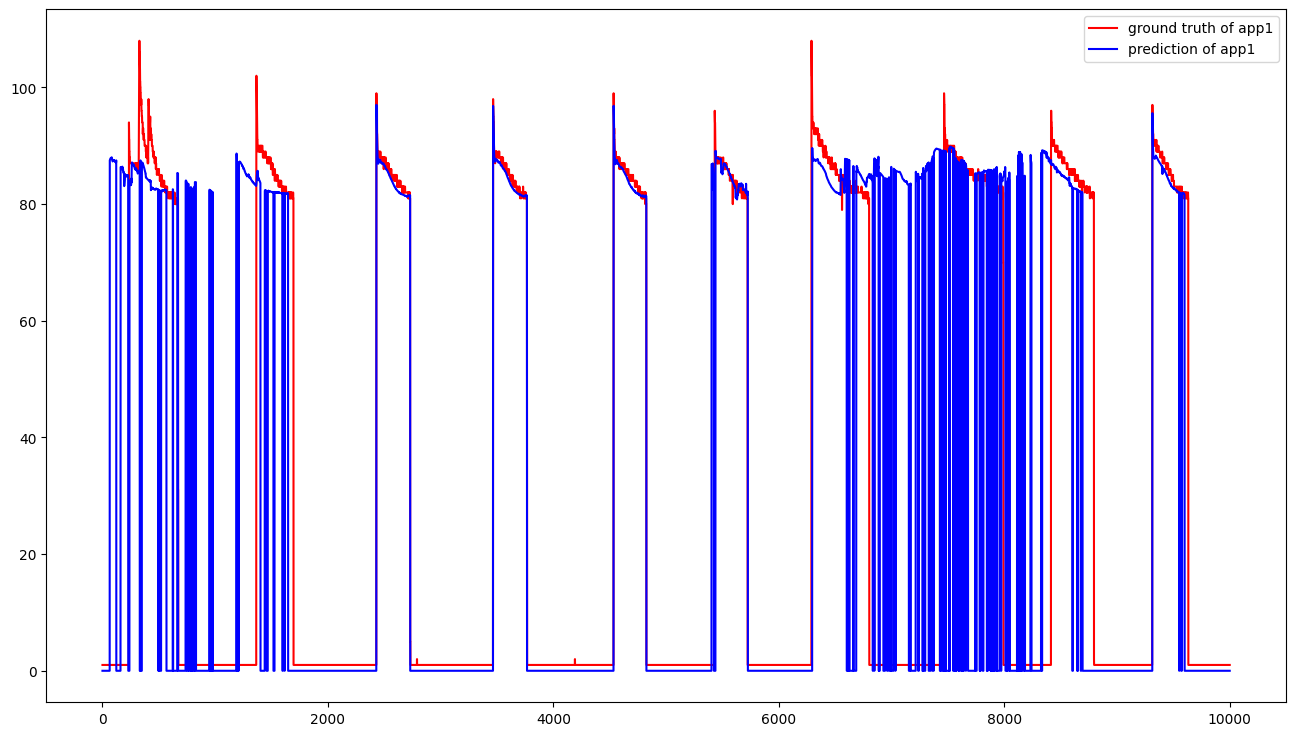

f1_energy_base: [0.76330369]
mae: [15.5873653]


In [31]:
tester_hybrid(app_num = 1)

In [57]:
train_regressor(20, model_save_dir1r_new, 1)

100%|██████████| 4480/4480 [06:00<00:00, 12.43it/s]


EPOCH: 1, average train loss: 0.00315115574137183


100%|██████████| 560/560 [00:22<00:00, 24.38it/s]


EPOCH: 1, average eval loss: 0.002819107576215174


100%|██████████| 4480/4480 [05:52<00:00, 12.70it/s]


...

EPOCH: 18, average train loss: 0.001376349182607685


100%|██████████| 560/560 [00:40<00:00, 13.90it/s]


EPOCH: 18, average eval loss: 0.002083162508539057


  3%|▎         | 117/4480 [00:10<06:37, 10.97it/s]


KeyboardInterrupt: 

In [48]:
train_classifier(20, model_save_dir1_new, 1)

100%|██████████| 4480/4480 [05:26<00:00, 13.74it/s]


EPOCH: 1, average train loss of classifier: 0.2702


100%|██████████| 560/560 [00:23<00:00, 23.83it/s]


>>> Mới lưu model tại epoch 1 với F1: 0.6423 <<<
EPOCH: 1, average eval loss: 0.7512, eval F1-score: 0.6423


100%|██████████| 4480/4480 [05:28<00:00, 13.65it/s]


...

EPOCH: 19, average train loss of classifier: 0.0611


100%|██████████| 560/560 [00:21<00:00, 26.32it/s]


EPOCH: 19, average eval loss: 0.7775, eval F1-score: 0.7447


  4%|▍         | 195/4480 [00:14<05:09, 13.86it/s]


KeyboardInterrupt: 

In [27]:
def tester_hybrid_new(app_num, device = device):
    ignore_threshold = threshold[app_num - 1]
    classifier_save_dir = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'classifier', f'classifier_app{app_num}_new.pth')
    regressor_save_dir = os.path.join(base_dir, 'checkpoints', 'advanced hybrid models', 'regressor', f'regressor_app{app_num}_new.pth')
    classifier = S2qwaClassifier().to(device)
    regressor = S2PwaRegressor().to(device)
    classifier.load_state_dict(torch.load(classifier_save_dir, weights_only=True))
    regressor.load_state_dict(torch.load(regressor_save_dir, weights_only=True))
    classifier.eval()
    regressor.eval()
    pred = []
    ground_truth = []
    with torch.no_grad():
        for batch_idx, (data_eval, target_eval) in enumerate(visualize_loader):
            data_eval = (data_eval - train_mean)/train_std
            data_eval = data_eval.to(device)
            target_eval = target_eval[:,[app_num - 1]].to(device)
            ground_truth += (target_eval.detach().cpu().reshape(-1).tolist())
            predc = (classifier(data_eval)>0).float()
            predr = (regressor(data_eval) * (app_max[app_num - 1] - app_min[app_num - 1]) + app_min[app_num - 1]).clamp(0)
            hybrid_pred = predc * predr
            pred += hybrid_pred.reshape(-1).detach().cpu().tolist()
    plt.figure(figsize = (16,9))
    plt.plot(ground_truth, color = 'r', label = f'ground truth of app{app_num}')
    plt.plot(pred, color = 'b', label = f'prediction of app{app_num}')
    plt.legend()
    plt.xlim((100000,200000))
    plt.show()
    print(f'f1_energy_base: {F1_energy_based_fixed(np.array(pred).reshape(-1,1), np.array(ground_truth).reshape(-1,1))}')
    print(f'mae: {MAE(np.array(pred).reshape(-1,1), np.array(ground_truth).reshape(-1,1))}')

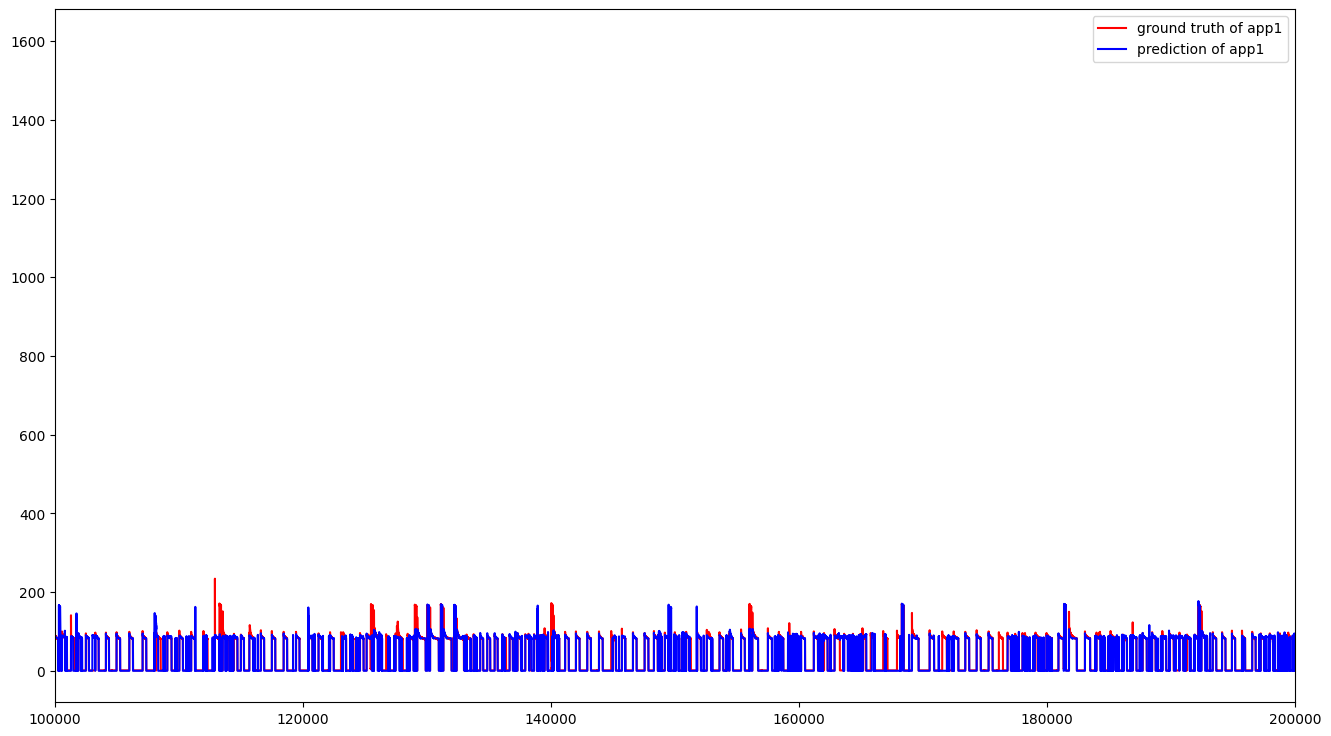

f1_energy_base: [0.76960883]
mae: [16.30878449]


In [28]:
res_new_1 = tester_hybrid_new(1)

In [46]:
res_app1 = tester_classifier(save_dir = model_save_dir1_new, app_num = 1)  # đã chỉnh train test

F1 score: 0.7875299989773694
[0 0 0 ... 1 1 1]
[0 0 0 ... 1 1 1]


In [24]:
confusion_matrix(res_app1[1], res_app1[0])

array([[12134,   131],
       [  117,  7848]])

In [17]:
train_classifier(20, model_save_dir2, 2, pos_weight = torch.tensor(4))

100%|██████████| 4480/4480 [06:16<00:00, 11.90it/s]


EPOCH: 1, average train loss of classifier: 0.0694


100%|██████████| 560/560 [00:38<00:00, 14.59it/s]


>>> new best model at 1 with F1: 0.7240 <<<
EPOCH: 1, average eval loss: 0.1035, eval F1-score: 0.7240


100%|██████████| 4480/4480 [06:48<00:00, 10.97it/s]


...

EPOCH: 19, average eval loss: 0.1973, eval F1-score: 0.7591


100%|██████████| 4480/4480 [05:12<00:00, 14.32it/s]


EPOCH: 20, average train loss of classifier: 0.0482


100%|██████████| 560/560 [00:21<00:00, 26.09it/s]


EPOCH: 20, average eval loss: 0.1497, eval F1-score: 0.7343
Done training model for appliance 2


In [18]:
train_regressor(20, model_save_dir2r, 2)

100%|██████████| 4480/4480 [05:52<00:00, 12.69it/s]


EPOCH: 1, average train loss: 0.05311108366170499


100%|██████████| 560/560 [00:22<00:00, 24.55it/s]


EPOCH: 1, average eval loss: 0.05850953350808205


100%|██████████| 4480/4480 [05:51<00:00, 12.76it/s]


...

EPOCH: 16, average train loss: 0.023669867786000914


100%|██████████| 560/560 [00:23<00:00, 23.57it/s]


EPOCH: 16, average eval loss: 0.05922365049565477


  7%|▋         | 301/4480 [00:24<05:38, 12.34it/s]


KeyboardInterrupt: 

In [47]:
res_app2 = tester_classifier(save_dir = model_save_dir2, app_num = 2)

F1 score: 0.6910245932090051
[0 0 0 ... 1 1 0]
[0 0 0 ... 1 0 1]


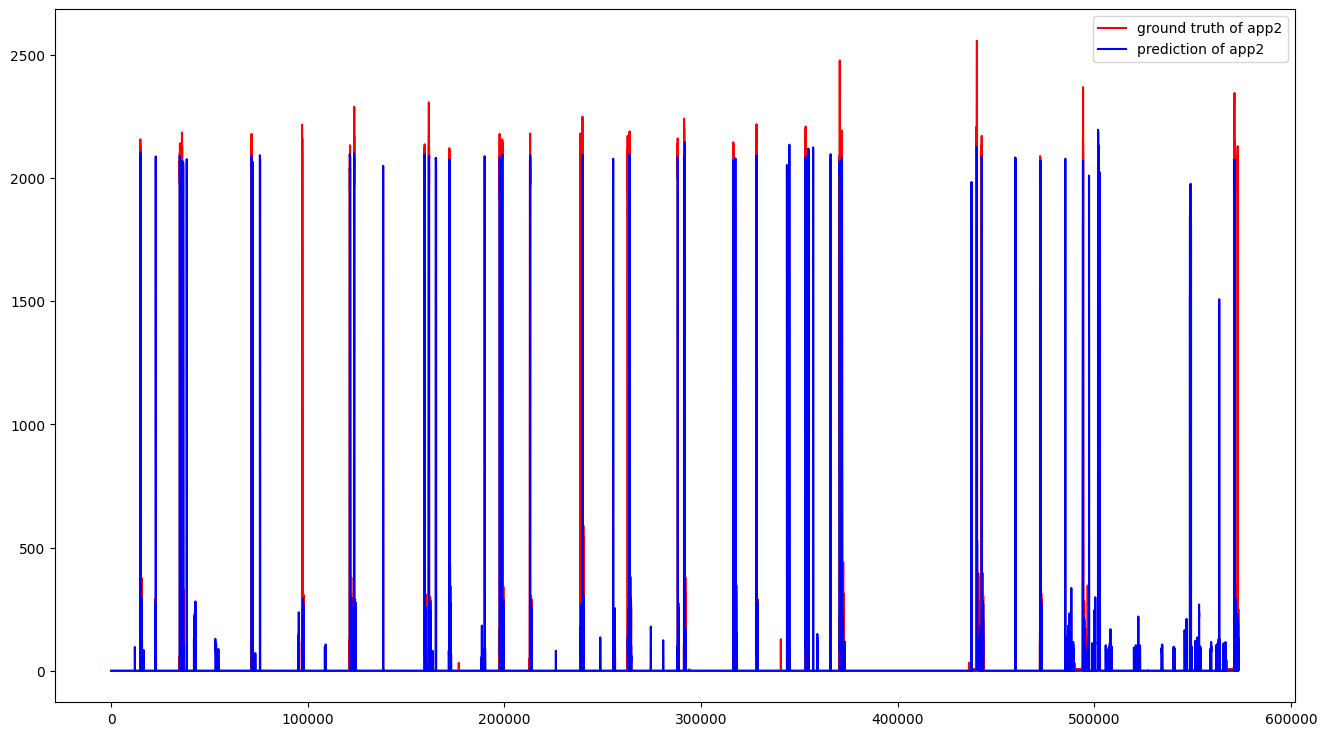

f1_energy_base: [0.69913278]
mae: [12.16690412]


In [25]:
res_app2_hybrid = tester_hybrid(app_num = 2)

# Confusion matrix

  0            1

0

1

In [19]:
confusion_matrix(res_app2[1], res_app2[0])                 # 0 bị đoán thành 1 quá nhiều vì pos weight quá lớn 

array([[19194,   238],
       [   21,   777]])

In [26]:
train_classifier(20, model_save_dir3, 3, pos_weight = torch.tensor(3))

100%|██████████| 4480/4480 [05:09<00:00, 14.49it/s]


EPOCH: 1, average train loss of classifier: 0.2105


100%|██████████| 560/560 [00:21<00:00, 25.89it/s]


>>> new best model at 1 with F1: 0.7181 <<<
EPOCH: 1, average eval loss: 0.1715, eval F1-score: 0.7181


100%|██████████| 4480/4480 [05:12<00:00, 14.36it/s]


...

EPOCH: 19, average eval loss: 0.3772, eval F1-score: 0.7299


100%|██████████| 4480/4480 [05:15<00:00, 14.20it/s]


EPOCH: 20, average train loss of classifier: 0.0327


100%|██████████| 560/560 [00:21<00:00, 25.76it/s]


EPOCH: 20, average eval loss: 0.3970, eval F1-score: 0.7412
Done training model for appliance 3


In [48]:
res_app3 = tester_classifier(save_dir = model_save_dir3, app_num = 3)

F1 score: 0.752289981845189
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]


In [50]:
train_regressor(20, model_save_dir3r, app_num = 3)

100%|██████████| 4480/4480 [06:36<00:00, 11.29it/s]


EPOCH: 1, average train loss: 0.1068683673139146


100%|██████████| 560/560 [00:28<00:00, 19.98it/s]


EPOCH: 1, average eval loss: 0.03761558914307638


100%|██████████| 4480/4480 [06:23<00:00, 11.68it/s]


...

EPOCH: 12, average train loss: 0.028625407323124817


100%|██████████| 560/560 [00:23<00:00, 24.02it/s]


EPOCH: 12, average eval loss: 0.034448126251144066


  1%|          | 47/4480 [00:04<06:29, 11.37it/s]


KeyboardInterrupt: 

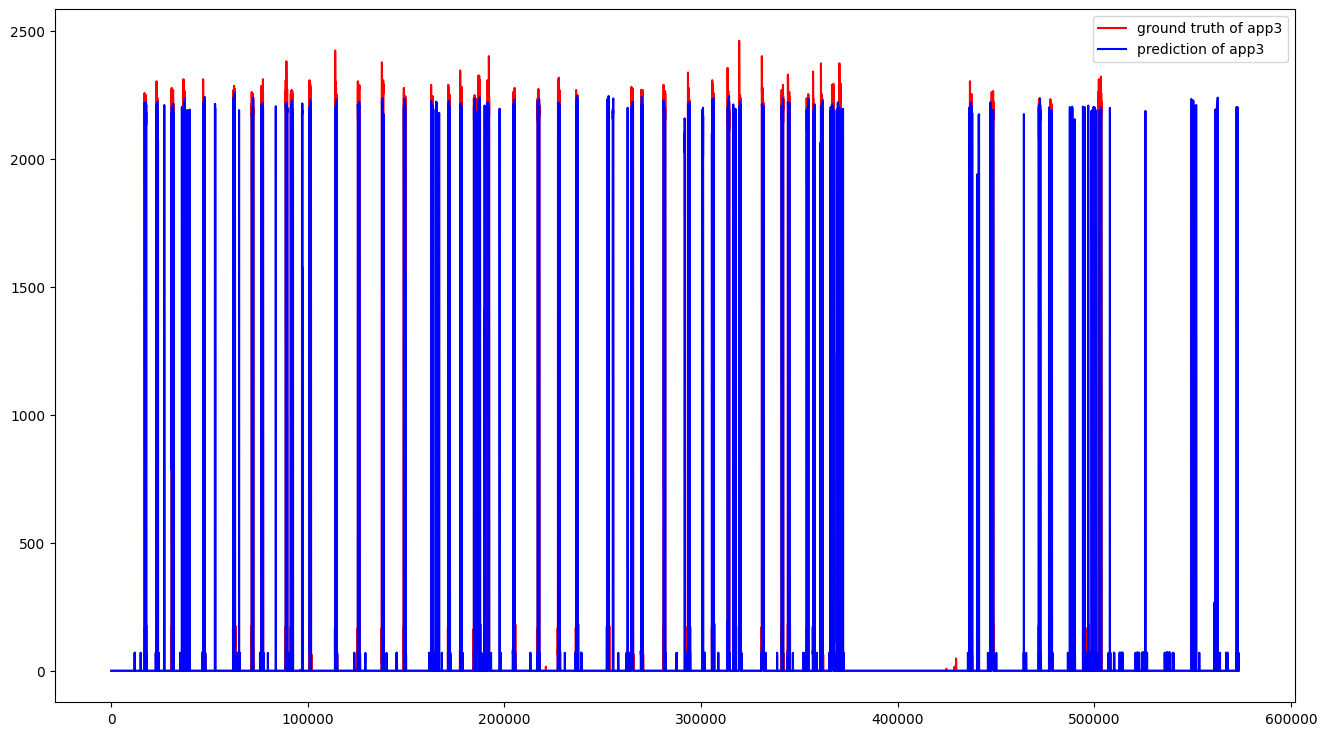

f1_energy_base: [0.81094552]
mae: [24.91032659]


In [51]:
res_app3_hybrid = tester_hybrid(app_num = 3)

In [23]:
train_classifier(20, model_save_dir5, 5, pos_weight = torch.tensor(9))

100%|██████████| 4480/4480 [05:05<00:00, 14.68it/s]


EPOCH: 1, average train loss of classifier: 0.1554


100%|██████████| 560/560 [00:20<00:00, 27.04it/s]


>>> new best model at 1 with F1: 0.6349 <<<
EPOCH: 1, average eval loss: 0.0702, eval F1-score: 0.6349


100%|██████████| 4480/4480 [05:05<00:00, 14.66it/s]


...

EPOCH: 19, average eval loss: 0.0646, eval F1-score: 0.6089


100%|██████████| 4480/4480 [05:34<00:00, 13.39it/s]


EPOCH: 20, average train loss of classifier: 0.0506


100%|██████████| 560/560 [00:28<00:00, 19.34it/s]


EPOCH: 20, average eval loss: 0.0545, eval F1-score: 0.6279
Done training model for appliance 5


In [49]:
res_app5 = tester_classifier(save_dir = model_save_dir5, app_num = 5)

F1 score: 0.5546035959937251
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]


In [52]:
train_regressor(20, model_save_dir5r, app_num = 5)

100%|██████████| 4480/4480 [06:01<00:00, 12.39it/s]


EPOCH: 1, average train loss: 0.2566466614059469


100%|██████████| 560/560 [00:23<00:00, 23.92it/s]


EPOCH: 1, average eval loss: 0.47270516383494915


100%|██████████| 4480/4480 [06:09<00:00, 12.14it/s]


...

EPOCH: 16, average train loss: 0.08169249240969358


100%|██████████| 560/560 [00:23<00:00, 23.48it/s]


EPOCH: 16, average eval loss: 0.11680632169009186


  6%|▌         | 267/4480 [00:21<05:40, 12.38it/s]


KeyboardInterrupt: 

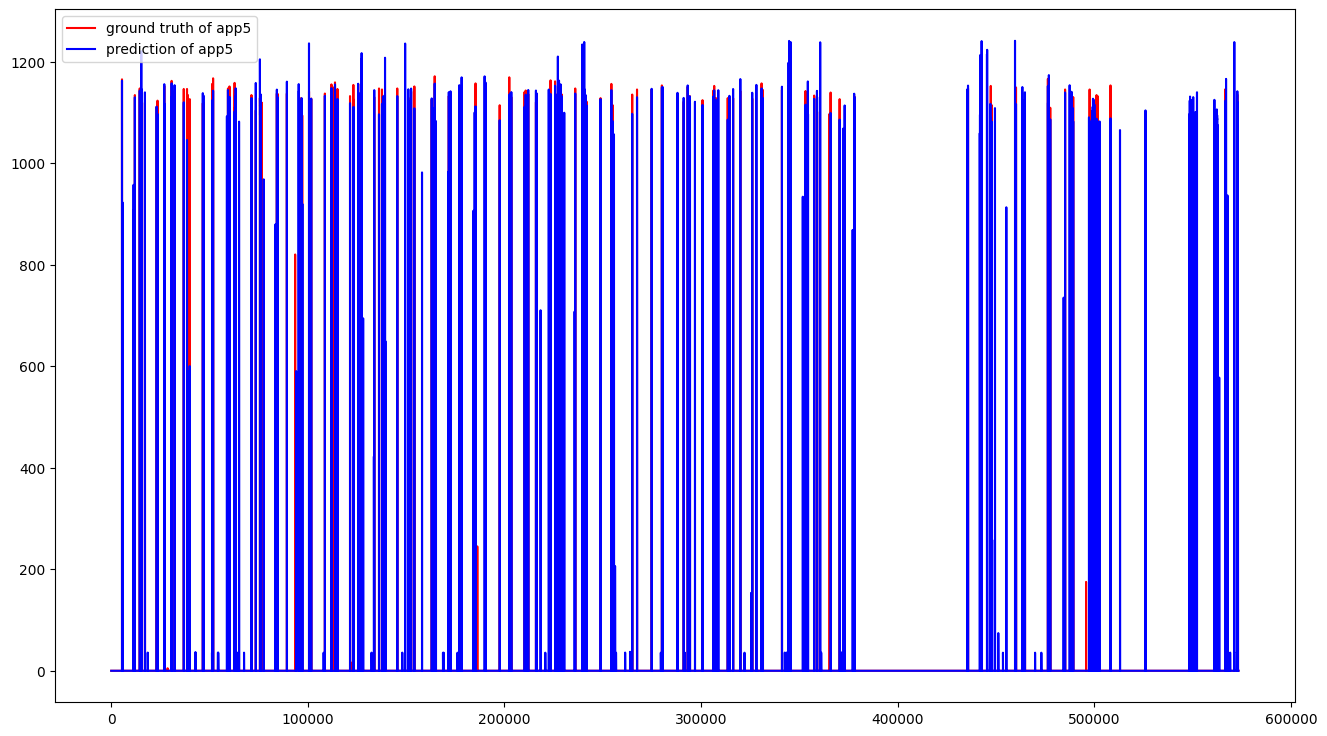

f1_energy_base: [0.55996778]
mae: [4.05773501]


In [53]:
res_app5_hybrid = tester_hybrid(app_num = 5)

In [22]:
confusion_matrix(res_app5[0], res_app5[1])             # có thể cần giảm pos weight

array([[19993,    32],
       [   53,   152]])

In [18]:
train_classifier(20, model_save_dir8, 8, pos_weight = torch.tensor(9))

100%|██████████| 4480/4480 [06:27<00:00, 11.55it/s]


EPOCH: 1, average train loss of classifier: 0.0357


100%|██████████| 560/560 [00:37<00:00, 15.09it/s]


>>> new best model at 1 with F1: 0.8675 <<<
EPOCH: 1, average eval loss: 0.0129, eval F1-score: 0.8675


100%|██████████| 4480/4480 [05:05<00:00, 14.66it/s]


...

EPOCH: 19, average eval loss: 0.0088, eval F1-score: 0.9160


100%|██████████| 4480/4480 [05:11<00:00, 14.38it/s]


EPOCH: 20, average train loss of classifier: 0.0113


100%|██████████| 560/560 [00:20<00:00, 26.95it/s]


EPOCH: 20, average eval loss: 0.0106, eval F1-score: 0.9168
Done training model for appliance 8


In [23]:
res_app8 = tester_classifier(save_dir = model_save_dir8, app_num = 8)

F1 score: 0.9117121410699393
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]


In [24]:
train_regressor(20, model_save_dir8r, app_num = 8)

100%|██████████| 4480/4480 [06:43<00:00, 11.09it/s]


EPOCH: 1, average train loss: 0.019351145486247594


100%|██████████| 560/560 [00:37<00:00, 14.76it/s]


EPOCH: 1, average eval loss: 0.015649764912918078


100%|██████████| 4480/4480 [07:02<00:00, 10.60it/s]


...

EPOCH: 12, average train loss: 0.013048771182522095


100%|██████████| 560/560 [00:38<00:00, 14.55it/s]


EPOCH: 12, average eval loss: 0.013736860614153556


 12%|█▏        | 549/4480 [00:51<06:09, 10.65it/s]


KeyboardInterrupt: 

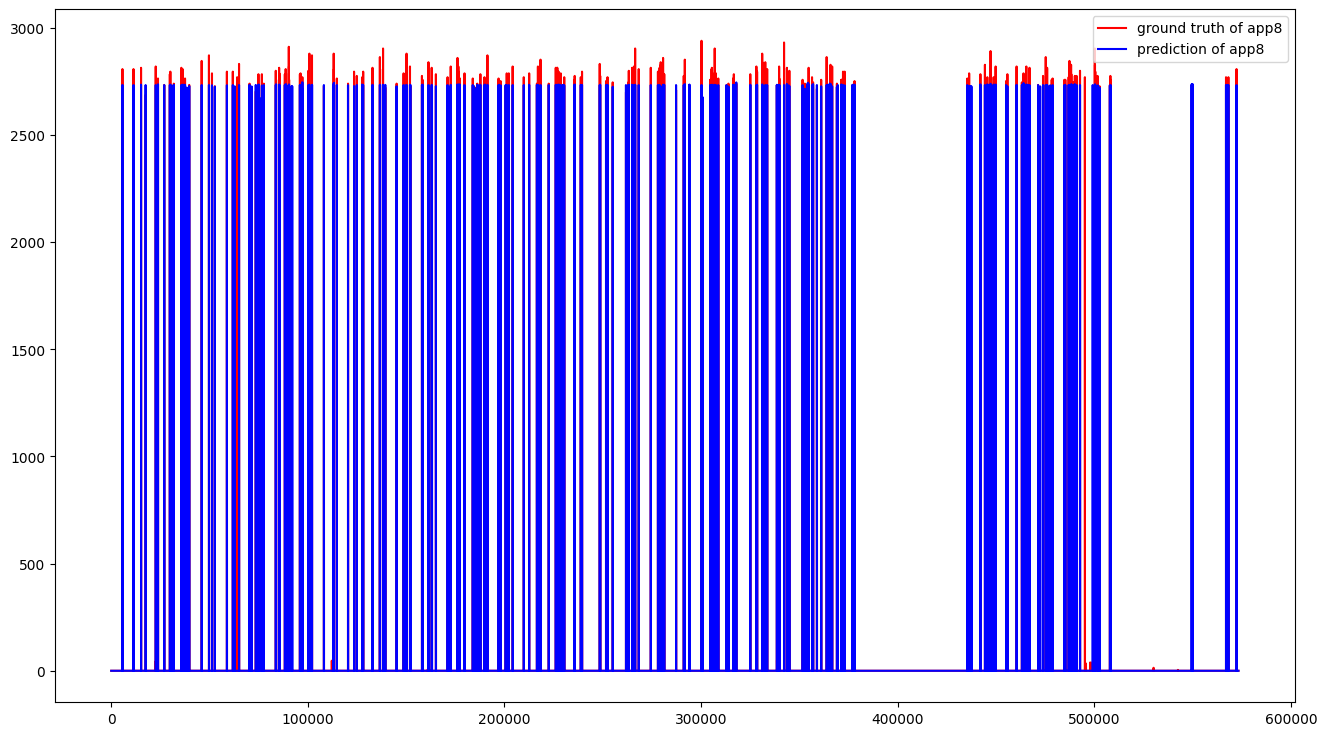

f1_energy_base: [0.90493136]
mae: [3.79417071]


([0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,

In [25]:
tester_hybrid(8)

In [25]:
confusion_matrix(res_app8[1], res_app8[0])

array([[20043,    21],
       [    1,   165]])